# Análise Exploratória de Dados — Carga de Energia do ONS

## Contexto do Problema

### O que é o ONS?
O **Operador Nacional do Sistema Elétrico (ONS)** é o órgão responsável pela
coordenação e controle da operação das instalações de geração e transmissão
de energia elétrica no Sistema Interligado Nacional (SIN).

### O que é carga energética?
A **carga energética** representa a demanda total de energia elétrica
consumida em um determinado período. Neste dataset, os valores estão
expressos em **MWmed (Megawatts médios)** — a potência média consumida
ao longo de um dia inteiro.

### Os subsistemas elétricos brasileiros
O Brasil é dividido em 4 subsistemas interligados:

| Sigla | Região | Característica principal |
|-------|--------|--------------------------|
| SE | Sudeste/Centro-Oeste | Maior concentração industrial e populacional |
| S | Sul | Alta sazonalidade climática, influência do frio |
| NE | Nordeste | Crescimento acelerado por expansão de renováveis |
| N | Norte | Menor demanda, grandes distâncias geográficas |

### Objetivo desta análise
Investigar o comportamento histórico da carga energética brasileira
entre **2015 e 2025**, identificando:
- Tendências de crescimento de longo prazo
- Diferenças regionais entre subsistemas
- Anomalias e outliers nos dados


## Carregamento dos dados

In [1]:

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import seaborn as sns

arquivos = [
    "../CsvDados/CARGA_ENERGIA_2015.csv",
    "../CsvDados/CARGA_ENERGIA_2016.csv",
    "../CsvDados/CARGA_ENERGIA_2017.csv",
    "../CsvDados/CARGA_ENERGIA_2018.csv",
    "../CsvDados/CARGA_ENERGIA_2019.csv",
    "../CsvDados/CARGA_ENERGIA_2020.csv",
    "../CsvDados/CARGA_ENERGIA_2021.csv",
    "../CsvDados/CARGA_ENERGIA_2022.csv",
    "../CsvDados/CARGA_ENERGIA_2023.csv",
    "../CsvDados/CARGA_ENERGIA_2024.csv",
    "../CsvDados/CARGA_ENERGIA_2025.csv",
]

DTYPES = {
    'id_subsistema': 'category',      
    'val_cargaenergiamwmed': 'float64' 
}

df = pd.concat(
    [pd.read_csv(arq, sep=';', encoding='utf-8',
                 dtype=DTYPES,
                 parse_dates=['din_instante']) 
     for arq in arquivos],
    ignore_index=True
)

print(f'✅ {df.shape[0]:,} linhas carregadas')

✅ 16,072 linhas carregadas


## Análise inicial da estrutura dos dados

In [2]:
df.head() 

,id_subsistema,nom_subsistema,din_instante,val_cargaenergiamwmed
0,N,Norte,2015-01-01,4541.005167
1,NE,Nordeste,2015-01-01,8308.521949
2,S,Sul,2015-01-01,7717.620040
3,SE,Sudeste/Centro-Oeste,2015-01-01,30874.778708
4,N,Norte,2015-01-02,4886.834250


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16072 entries, 0 to 16071
Data columns (total 4 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   id_subsistema          16072 non-null  category      
 1   nom_subsistema         16072 non-null  str           
 2   din_instante           16072 non-null  datetime64[us]
 3   val_cargaenergiamwmed  16068 non-null  float64       
dtypes: category(1), datetime64[us](1), float64(1), str(1)
memory usage: 392.5 KB


In [4]:
df.describe()

,din_instante,val_cargaenergiamwmed
count,16072,16068.000000
mean,2020-07-01 12:00:00,16964.393600
min,2015-01-01 00:00:00,3969.773875
25%,2017-10-01 00:00:00,8408.050559
50%,2020-07-01 12:00:00,11260.678479
75%,2023-04-02 00:00:00,21024.181104
max,2025-12-31 00:00:00,55584.896708
std,NaN,13103.657723


Desvio padrão alto, uma causa é a disparidade da demanda energética entre as regiões

In [5]:
df.isnull().sum()

id_subsistema            0
nom_subsistema           0
din_instante             0
val_cargaenergiamwmed    4
dtype: int64

In [6]:
df[df['val_cargaenergiamwmed'].isnull()]

,id_subsistema,nom_subsistema,din_instante,val_cargaenergiamwmed
392,N,Norte,2015-04-09,NaN
393,NE,Nordeste,2015-04-09,NaN
394,S,Sul,2015-04-09,NaN
395,SE,Sudeste/Centro-Oeste,2015-04-09,NaN


Foram identificados valores ausentes no dia 09/04/2015 para todos os subsistemas. Como os dados anteriores e posteriores estavam disponíveis e consistentes, optou-se por utilizar interpolação linear para estimar os valores faltantes.

## Tratamento de valores ausentes

In [7]:
# Ordenar por subsistema e data — essencial para a interpolação funcionar corretamente
df = df.sort_values(['id_subsistema', 'din_instante']).reset_index(drop=True)

# Interpolar dentro de cada subsistema separadamente
df['val_cargaenergiamwmed'] = (
    df.groupby('id_subsistema')['val_cargaenergiamwmed']
    .transform(lambda x: x.interpolate(method='linear'))
)

# Confirmar que os nulos foram preenchidos
nulos_restantes = df['val_cargaenergiamwmed'].isnull().sum()
print(f'✅ Nulos restantes: {nulos_restantes}')

# Verificar o dia que tinha nulos
print('\n📅 Dia 09/04/2015 após interpolação:')
print(df[df['din_instante'] == '2015-04-09'][['id_subsistema', 'din_instante', 'val_cargaenergiamwmed']])

✅ Nulos restantes: 0

📅 Dia 09/04/2015 após interpolação:
      id_subsistema din_instante  val_cargaenergiamwmed
98                N   2015-04-09            5388.354417
4116             NE   2015-04-09           10523.588220
8134              S   2015-04-09           11472.557228
12152            SE   2015-04-09           37295.256378


Os valores ausentes foram tratados utilizando interpolação linear dentro de cada subsistema separadamente. Essa abordagem preserva o comportamento temporal específico de cada região do sistema elétrico brasileiro, evitando distorções causadas por médias globais.

In [8]:
df.dtypes

id_subsistema                  category
nom_subsistema                      str
din_instante             datetime64[us]
val_cargaenergiamwmed           float64
dtype: object

In [9]:
print(df.isnull().sum())

id_subsistema            0
nom_subsistema           0
din_instante             0
val_cargaenergiamwmed    0
dtype: int64


In [10]:
print(f'Duplicados encontrados: {df.duplicated().sum()}')

Duplicados encontrados: 0


In [11]:
df['id_subsistema'].unique()

['N', 'NE', 'S', 'SE']
Categories (4, str): ['N', 'NE', 'S', 'SE']

In [12]:
df.describe()

,din_instante,val_cargaenergiamwmed
count,16072,16072.000000
mean,2020-07-01 12:00:00,16964.195876
min,2015-01-01 00:00:00,3969.773875
25%,2017-10-01 00:00:00,8408.050559
50%,2020-07-01 12:00:00,11260.678479
75%,2023-04-02 00:00:00,21024.181104
max,2025-12-31 00:00:00,55584.896708
std,NaN,13103.496671


## Analise dos Dados

In [13]:
# Linha com menor valor
minimo = df.loc[df['val_cargaenergiamwmed'].idxmin()]

print('🔽 Menor valor encontrado:')
print(minimo)

# Linha com maior valor
maximo = df.loc[df['val_cargaenergiamwmed'].idxmax()]

print('\n🔼 Maior valor encontrado:')
print(maximo)

🔽 Menor valor encontrado:
id_subsistema                             NE
nom_subsistema                      Nordeste
din_instante             2018-08-25 00:00:00
val_cargaenergiamwmed            3969.773875
Name: 5350, dtype: object

🔼 Maior valor encontrado:
id_subsistema                              SE
nom_subsistema           Sudeste/Centro-Oeste
din_instante              2025-02-18 00:00:00
val_cargaenergiamwmed            55584.896708
Name: 15755, dtype: object


In [14]:
df['ano'] = df['din_instante'].dt.year
df['mes'] = df['din_instante'].dt.month
df['dia_semana'] = df['din_instante'].dt.dayofweek # 0=Segunda, 6=Domingo
df['is_weekend'] = df['dia_semana'].isin([5, 6])

Foram criadas variáveis temporais derivadas da coluna de data, permitindo análises sazonais e comportamentais da carga energética ao longo dos anos, meses e dias da semana. Essas variáveis auxiliam na identificação de padrões temporais e possíveis anomalias no consumo de energia.

In [15]:
df[
    (df['nom_subsistema'] == 'Nordeste') &
    (df['din_instante'].between('2018-08-20', '2018-08-30'))
][['din_instante', 'val_cargaenergiamwmed']]

,din_instante,val_cargaenergiamwmed
5345,2018-08-20,10141.094292
5346,2018-08-21,10281.005000
5347,2018-08-22,10275.046333
5348,2018-08-23,10348.784458
5349,2018-08-24,10451.198208
5350,2018-08-25,3969.773875
5351,2018-08-26,9196.706042
5352,2018-08-27,10129.237208
5353,2018-08-28,10338.145917
5354,2018-08-29,10199.799542


A análise temporal do menor valor registrado revelou comportamento inconsistente em relação aos dias adjacentes. Enquanto os valores do subsistema Nordeste permaneceram próximos de 10 mil MWmed antes e após 25/08/2018, foi identificado um valor abruptamente inferior de aproximadamente 4 mil MWmed nessa data.

Esse comportamento sugere a presença de um possível outlier temporal, potencialmente associado a falha de medição, inconsistência operacional ou evento excepcional no sistema elétrico.

In [16]:
df[
    (df['nom_subsistema'] == 'Sudeste/Centro-Oeste') &
    (df['din_instante'].between('2025-02-13', '2025-02-23'))
][['din_instante', 'val_cargaenergiamwmed']]

,din_instante,val_cargaenergiamwmed
15750,2025-02-13,53428.736708
15751,2025-02-14,52974.155083
15752,2025-02-15,49033.897375
15753,2025-02-16,46368.360792
15754,2025-02-17,54572.624875
15755,2025-02-18,55584.896708
15756,2025-02-19,54696.465042
15757,2025-02-20,55196.378625
15758,2025-02-21,54703.323833
15759,2025-02-22,49920.815333


A análise do maior valor registrado no dataset indica comportamento consistente com os dias adjacentes. Entre 13/02/2025 e 23/02/2025, o subsistema Sudeste/Centro-Oeste apresentou valores elevados e relativamente estáveis, variando entre aproximadamente 46 mil e 55 mil MWmed.

O pico observado em 18/02/2025 (55.584 MWmed) não representa uma ruptura abrupta na série temporal, mas sim um aumento gradual dentro de um período de alta demanda energética na região.

Esse comportamento sugere que o valor máximo identificado possui maior probabilidade de representar um evento real do sistema elétrico, e não uma inconsistência ou erro de medição.

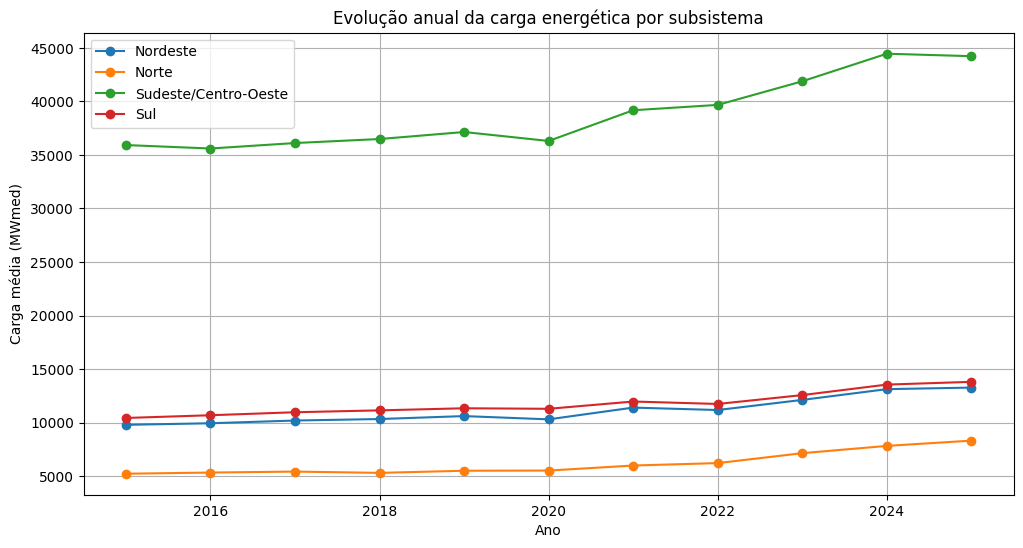

In [17]:
carga_anual = (
    df.groupby(['ano', 'nom_subsistema'])['val_cargaenergiamwmed']
    .mean()
    .reset_index()
)

plt.figure(figsize=(12, 6))

for subsistema in carga_anual['nom_subsistema'].unique():
    dados = carga_anual[carga_anual['nom_subsistema'] == subsistema]

    plt.plot(
        dados['ano'],
        dados['val_cargaenergiamwmed'],
        marker='o',
        label=subsistema
    )

plt.title('Evolução anual da carga energética por subsistema')
plt.xlabel('Ano')
plt.ylabel('Carga média (MWmed)')

plt.legend()
plt.grid(True)

plt.savefig(
    '../graficos/carga_anual_subsistemas.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

É observada a discrepância dos valores da região Sudeste/Centro-Oeste em relação às demais regiões. Um fator que poderia ser analisado futuramente, com apoio de outros dados, seria a diferença individual entre os estados do Centro-Oeste e do Sudeste, já que ambos os subsistemas estão agrupados na mesma categoria do ONS.

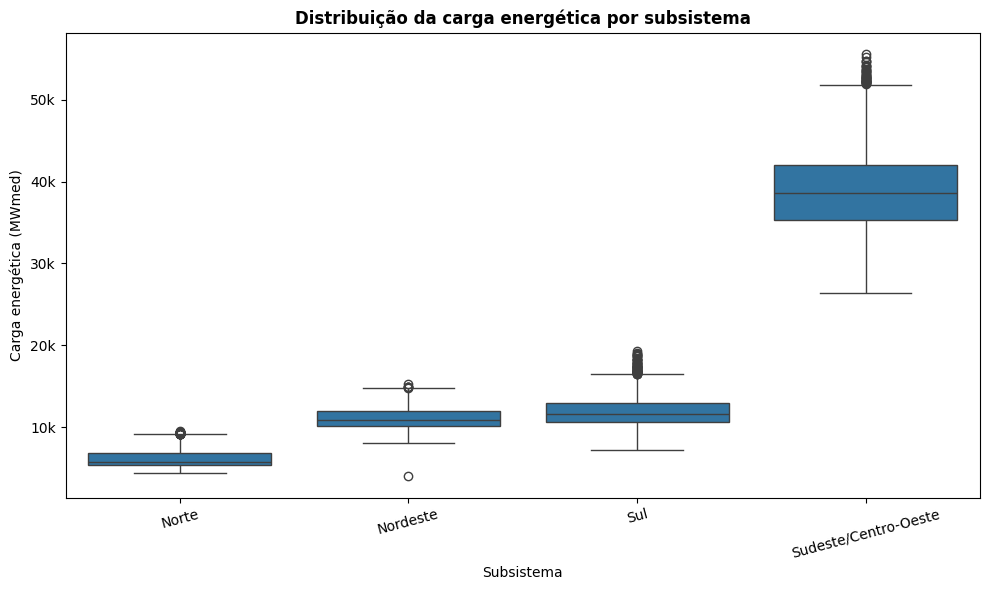

In [18]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=df,
    x='nom_subsistema',
    y='val_cargaenergiamwmed',
    ax=ax
)

ax.set_title('Distribuição da carga energética por subsistema', fontweight='bold')
ax.set_xlabel('Subsistema')
ax.set_ylabel('Carga energética (MWmed)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('../graficos/boxplot_subsistemas.png', dpi=300, bbox_inches='tight')
plt.show()

O boxplot evidencia diferenças significativas na distribuição da carga energética entre os subsistemas brasileiros.

O subsistema Sudeste/Centro-Oeste apresenta valores substancialmente superiores aos demais, além de maior dispersão dos dados, indicando elevada variabilidade no consumo energético ao longo do período analisado.

Também foram identificados diversos outliers superiores, principalmente nas regiões Sudeste/Centro-Oeste e Sul, sugerindo períodos de demanda excepcionalmente elevada.

No subsistema Nordeste, destaca-se um outlier inferior próximo de 4 mil MWmed, compatível com o valor mínimo anteriormente analisado, reforçando a hipótese de possível anomalia ou inconsistência temporal nos dados.

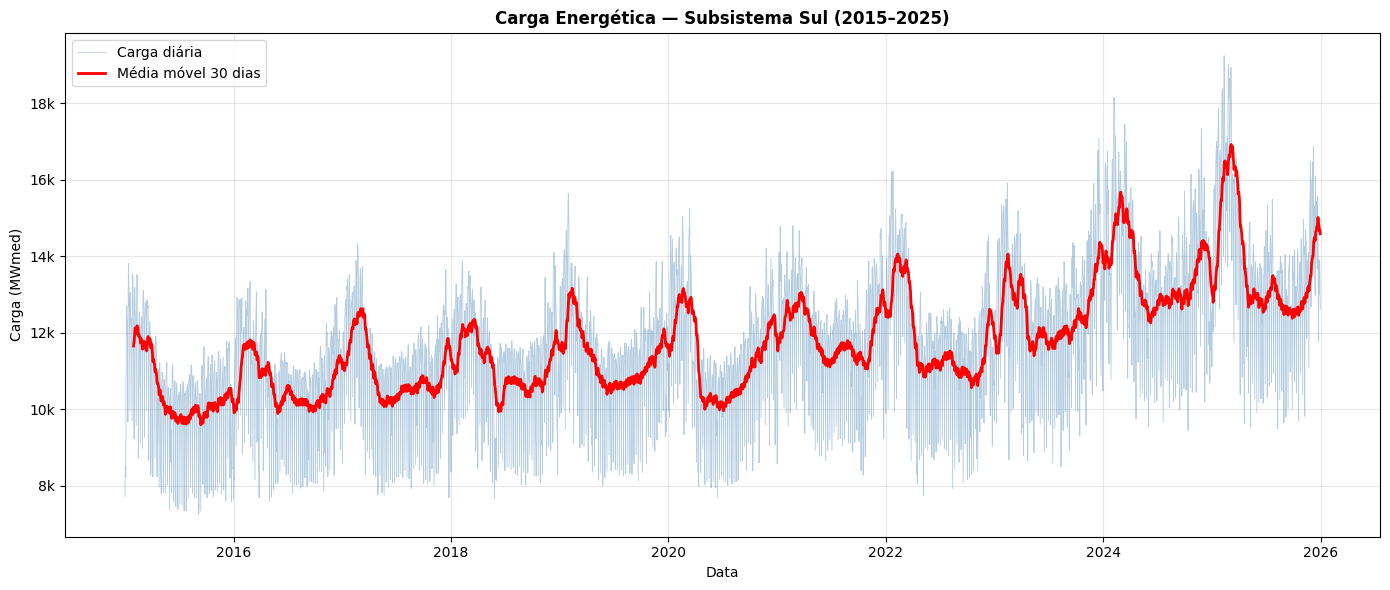

In [19]:
dados_sul = df[df['nom_subsistema'] == 'Sul'].copy().set_index('din_instante')

mm_30 = dados_sul['val_cargaenergiamwmed'].rolling(30).mean()

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(dados_sul.index, dados_sul['val_cargaenergiamwmed'],
        color='steelblue', linewidth=0.6, alpha=0.4, label='Carga diária')

ax.plot(mm_30.index, mm_30.values,
        color='red', linewidth=2, label='Média móvel 30 dias')

ax.set_title('Carga Energética — Subsistema Sul (2015–2025)', fontweight='bold')
ax.set_xlabel('Data')
ax.set_ylabel('Carga (MWmed)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../graficos/carga_energetica_subsistema_Sul.png', dpi=300, bbox_inches='tight')
plt.show()

In [20]:
top_5_2024 = dados_sul[(dados_sul['ano'] == 2024)] \
    .sort_values('val_cargaenergiamwmed', ascending=False).head(5)

top_5_2025 = dados_sul[(dados_sul['ano'] == 2025)] \
    .sort_values('val_cargaenergiamwmed', ascending=False).head(5)

print("📅 Maiores cargas:")
print(top_5_2024[['din_instante', 'val_cargaenergiamwmed']])

print("\n📅 Maiores cargas:")
print(top_5_2025[['din_instante', 'val_cargaenergiamwmed']])

📅 Maiores cargas:


KeyError: "['din_instante'] not in index"

A análise temporal do subsistema Sul sugere que parte dos valores classificados como outliers no boxplot representa, na realidade, períodos recentes de aumento consistente da demanda energética.

Os maiores valores observados concentram-se principalmente nos anos de 2024 e 2025, com ocorrências em dias consecutivos e sem rupturas abruptas na série temporal. Esse comportamento indica maior probabilidade de crescimento estrutural da carga energética do que inconsistências nos dados.

Esse resultado evidencia uma limitação do boxplot em séries temporais longas, já que valores recentes podem ser classificados como outliers apenas por estarem acima da distribuição histórica acumulada.

Os valores maiores, na maioria das vezes, ocorre durante o verão.